# A table you can see

A heatmap colors a rectangle of numbers. It is the right picture when both the row and the column carry meaning, and the cell is the amount.

North Lab, jobs:

$$
\begin{bmatrix}
4 & 5 & 5 & 6 & 7 \\
6 & 6 & 7 & 7 & 8 \\
3 & 4 & 4 & 5 & 4 \\
5 & 5 & 6 & 6 & 7
\end{bmatrix}
$$

Rows are Ada, Grace, Alan, Linus. Columns are Mon through Fri. The darkest honest color should mean "more jobs", and the scale should start at $0$ because $0$ jobs is the real bottom of a count. The largest cell is $8$. If the scale runs from $0$ to $8$, Alan's Monday $3$ is a light cell, not a blank one.


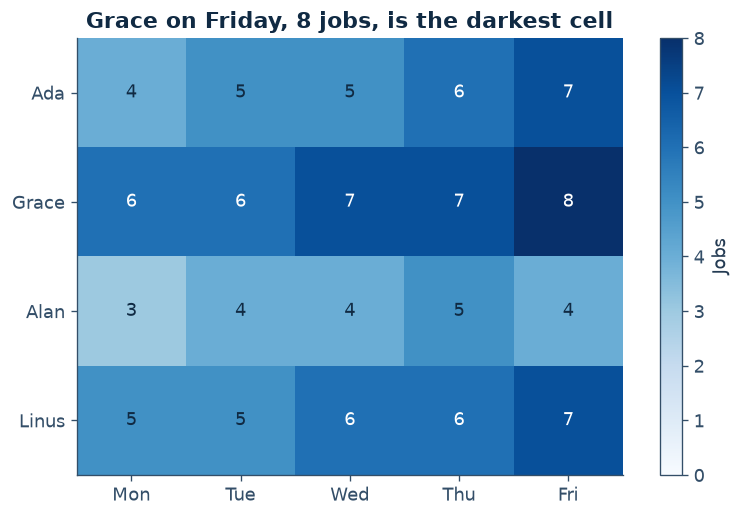

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Counts from 0 to 8. Every cell is labeled with the integer it encodes.
jobs = [
    [4, 5, 5, 6, 7],
    [6, 6, 7, 7, 8],
    [3, 4, 4, 5, 4],
    [5, 5, 6, 6, 7],
]
flat = [value for row in jobs for value in row]
assert min(flat) == 3 and max(flat) == 8
assert sum(flat) == 110
fig, ax = plt.subplots(constrained_layout=True)
image = ax.imshow(jobs, cmap="Blues", vmin=0, vmax=8)
ax.set_xticks(range(5), ["Mon", "Tue", "Wed", "Thu", "Fri"])
ax.set_yticks(range(4), ["Ada", "Grace", "Alan", "Linus"])
ax.grid(False)
for row in range(4):
    for col in range(5):
        ink = "white" if jobs[row][col] >= 6 else INK
        ax.text(col, row, str(jobs[row][col]), ha="center", va="center", color=ink)
bar = fig.colorbar(image, ax=ax)
bar.set_label("Jobs")
ax.set_title("Grace on Friday, 8 jobs, is the darkest cell")
assert image.get_clim() == (0, 8)


## Starting the scale at the smallest cell

The smallest cell is $3$, not $0$. If the colors run from $3$ to $8$, Alan's Monday becomes the lightest color the scale has. A reader can call it empty. The number has not changed. Only the bottom of the color scale moved. For counts, keep the bottom at zero unless you have a stated reason and you print that reason in the title.


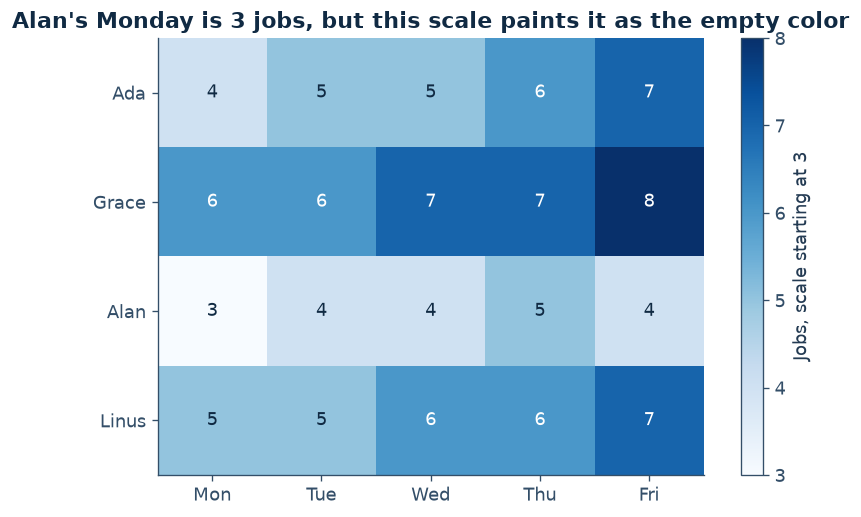

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Same matrix, color bottom at 3. Alan's 3 now looks like a zero on this scale.
jobs = [
    [4, 5, 5, 6, 7],
    [6, 6, 7, 7, 8],
    [3, 4, 4, 5, 4],
    [5, 5, 6, 6, 7],
]
fig, ax = plt.subplots(constrained_layout=True)
image = ax.imshow(jobs, cmap="Blues", vmin=3, vmax=8)
ax.set_xticks(range(5), ["Mon", "Tue", "Wed", "Thu", "Fri"])
ax.set_yticks(range(4), ["Ada", "Grace", "Alan", "Linus"])
ax.grid(False)
for row in range(4):
    for col in range(5):
        ink = "white" if jobs[row][col] >= 6 else INK
        ax.text(col, row, str(jobs[row][col]), ha="center", va="center", color=ink)
bar = fig.colorbar(image, ax=ax)
bar.set_label("Jobs, scale starting at 3")
ax.set_title("Alan's Monday is 3 jobs, but this scale paints it as the empty color")
assert image.get_clim() == (3, 8)


## A pitfall

A rainbow scale adds bright bands where the numbers only stepped by $1$. The eye treats a band as a boundary. On this table the steps are small, and a blue scale plus the printed integer is enough. If you remove the integers, the color must still have a labeled colorbar, and the reader must be able to recover a cell to the nearest job.

## What to carry forward

Color a matrix when both directions mean something. For these counts the scale is $0$ to $8$, every cell prints its integer, and the darkest cell is Grace on Friday.
